In [1]:
import pandas as pd


# Load data
train_df = pd.read_csv('~/data/Germany_time_zone/all/train_with_all.csv')
test_df = pd.read_csv('~/data/Germany_time_zone/all/test_with_all.csv')

# Convert to UTC while handling DST ambiguities
train_df['ds'] = pd.to_datetime(train_df['ds']).dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert('UTC')
test_df['ds'] = pd.to_datetime(test_df['ds']).dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert('UTC')

# Check date ranges
print("First date in train_df:", train_df['ds'].min())
print("Last date in train_df:", train_df['ds'].max())
print("First date in test_df:", test_df['ds'].min())
print("Last date in test_df:", test_df['ds'].max())


calendar_features = ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 
                     'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend']
gas_price_features = ['gas_price']
synthetic_price_features = ['co2_emission_allowances', 'synthetic_price']
load_features = ['load']
renewable_features = ['renewable', 'non_renewable']
cross_border_features = ['cross_border_trading']

# Define the exogenous variable lists
stat_exog_list = [] 
hist_exog_list = (
    calendar_features
    + gas_price_features
    + synthetic_price_features
    + load_features
    + renewable_features
    + cross_border_features
)

futr_exog_list = (
    calendar_features
)


First date in train_df: 2018-09-30 22:00:00+00:00
Last date in train_df: 2023-12-31 22:00:00+00:00
First date in test_df: 2023-12-31 23:00:00+00:00
Last date in test_df: 2024-12-31 22:00:00+00:00


In [2]:
train_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,...,day_of_week_cos,hour_sin,hour_cos,gas_price,cross_border_trading,non_renewable,renewable,load,co2_emission_allowances,synthetic_price
0,2018-09-30 22:00:00+00:00,59.53,electricity_prices,0,10,0,0,0,-0.866025,0.5,...,1.0,0.000000,1.000000,26.076,-3352.17,28463.26,12633.01,42928.26,20.3,55.530909
1,2018-09-30 23:00:00+00:00,56.10,electricity_prices,0,10,1,0,0,-0.866025,0.5,...,1.0,0.258819,0.965926,26.076,-3766.75,28254.16,12700.17,41669.59,20.3,55.530909
2,2018-10-01 00:00:00+00:00,51.41,electricity_prices,0,10,2,0,0,-0.866025,0.5,...,1.0,0.500000,0.866025,26.076,-4556.14,28222.05,12732.32,40900.29,20.3,55.530909
3,2018-10-01 01:00:00+00:00,47.38,electricity_prices,0,10,3,0,0,-0.866025,0.5,...,1.0,0.707107,0.707107,26.076,-3055.86,28497.02,12949.38,41735.54,20.3,55.530909
4,2018-10-01 02:00:00+00:00,47.59,electricity_prices,0,10,4,0,0,-0.866025,0.5,...,1.0,0.866025,0.500000,26.076,-2241.89,29026.40,13789.26,43295.32,20.3,55.530909


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# High-quality plotting parameters
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2,
    'savefig.dpi': 600,
    'grid.alpha': 0.6,
    'font.family': 'serif'
})

# Ensure ds is datetime without timezone for proper grouping
train_df['ds'] = pd.to_datetime(train_df['ds']).dt.tz_localize(None)
test_df['ds'] = pd.to_datetime(test_df['ds']).dt.tz_localize(None)

# Select only numeric columns (exclude 'ds' and any non-numeric fields)
numeric_cols = train_df.select_dtypes(include=['number']).columns

# Compute daily averages for numeric columns
train_daily_avg = train_df.groupby(train_df['ds'].dt.date)[numeric_cols].mean()
test_daily_avg = test_df.groupby(test_df['ds'].dt.date)[numeric_cols].mean()

# Convert index back to datetime for plotting
train_daily_avg.index = pd.to_datetime(train_daily_avg.index)
test_daily_avg.index = pd.to_datetime(test_daily_avg.index)

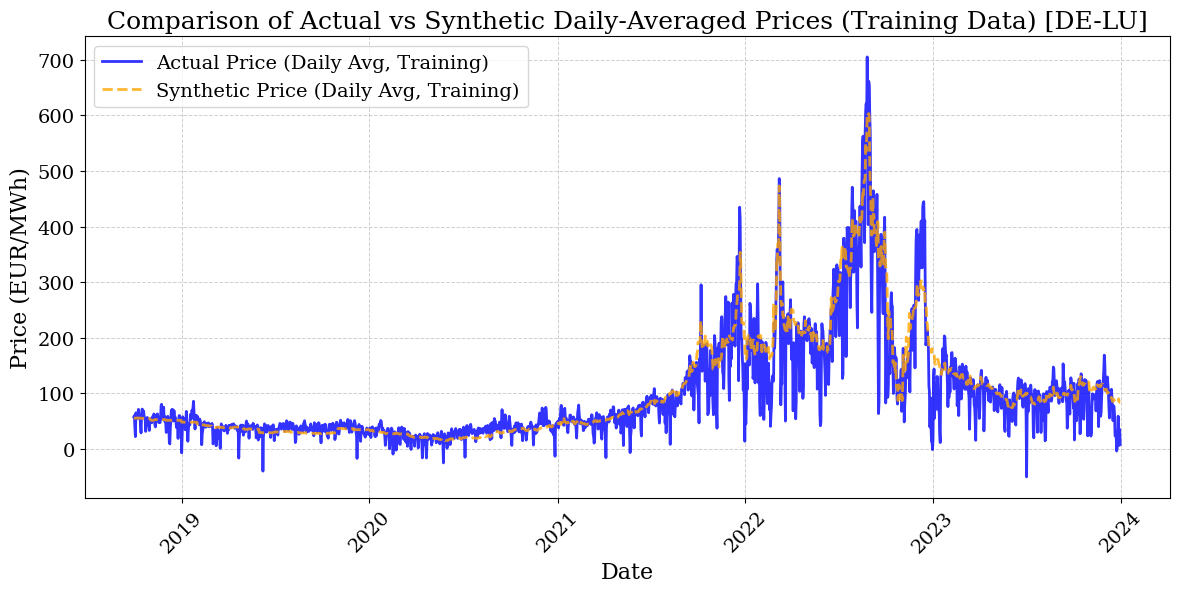

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(train_daily_avg.index, train_daily_avg['y'], label='Actual Price (Daily Avg, Training)', color='blue', alpha=0.8, rasterized=True)
plt.plot(train_daily_avg.index, train_daily_avg['synthetic_price'], label='Synthetic Price (Daily Avg, Training)', color='orange', linestyle="--", alpha=0.8, rasterized=True)
plt.title('Comparison of Actual vs Synthetic Daily-Averaged Prices (Training Data) [DE-LU]')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.grid(True, linestyle="--", linewidth=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.savefig("actual_vs_synthetic_daily_avg_training.png", dpi=600, bbox_inches="tight")
plt.show()

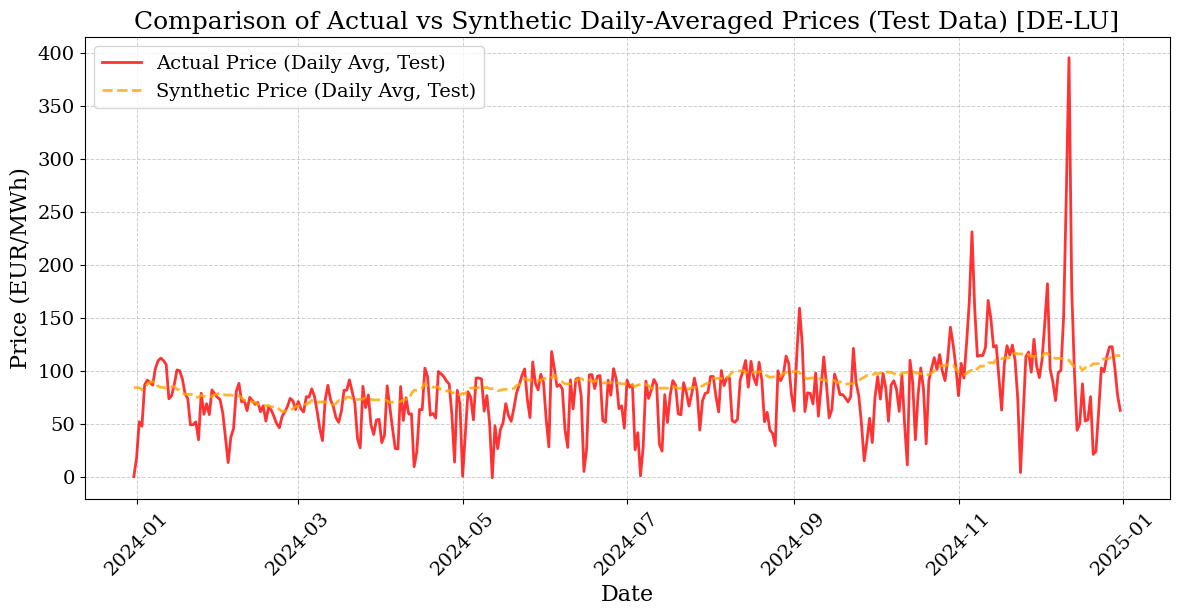

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(test_daily_avg.index, test_daily_avg['y'], label='Actual Price (Daily Avg, Test)', color='red', alpha=0.8, rasterized=True)
plt.plot(test_daily_avg.index, test_daily_avg['synthetic_price'], label='Synthetic Price (Daily Avg, Test)', color='orange', linestyle="--", alpha=0.8, rasterized=True)
plt.title('Comparison of Actual vs Synthetic Daily-Averaged Prices (Test Data) [DE-LU]')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.grid(True, linestyle="--", linewidth=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.savefig("actual_vs_synthetic_daily_avg_test.png", dpi=600, bbox_inches="tight")
plt.show()